<a href="https://colab.research.google.com/github/deetijasmitha/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/deetijasmitha/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Abstract

This study asks whether February 2026 content-performance signals can help identify content that went dark in March 2026. The analysis uses aggregated Google Search Console and Google Analytics 4 signals from the FlyRank Internship Warehouse and evaluates 29,729 eligible content-client records. A Logistic Regression model was evaluated using a client-grouped test split and achieved a ROC-AUC of **0.7056**, compared with **0.5736** for the rule-based baseline. The results provide directional evidence that historical performance signals can support content-review prioritization. The findings are intended for decision support and do not establish causality or guarantee future performance.


## 1. Question

### Research question

Can February 2026 content-performance signals help identify content that went dark in March 2026?

### Decision supported

The analysis supports a content and SEO prioritization decision: which content items should be reviewed first when resources for refresh or improvement are limited.

The goal is decision support. The analysis identifies directional signals for prioritization and does not claim that the observed signals cause future performance changes.


In [10]:
# ML-11 — Section 1: Research question

research_question = """
Can February 2026 content-performance signals help identify content
that went dark in March 2026, and can those signals support a ranked
content-review workflow?
"""

decision_supported = """
The analysis supports a content and SEO prioritization decision:
which content items should be reviewed first when resources for
refresh or improvement are limited.
"""

print("========== ML-11 SECTION 1 ==========")

print("\nResearch question:")
print(research_question.strip())

print("\nDecision supported:")
print(decision_supported.strip())

print("\nEvidence framing:")
print("Directional decision-support evidence, not a causal guarantee.")

========== ML-11 SECTION 1 ==========

Research question:
Can February 2026 content-performance signals help identify content
that went dark in March 2026, and can those signals support a ranked
content-review workflow?

Decision supported:
The analysis supports a content and SEO prioritization decision:
which content items should be reviewed first when resources for
refresh or improvement are limited.

Evidence framing:
Directional decision-support evidence, not a causal guarantee.


## 2. Data

### Data source

The analysis uses the FlyRank Internship Warehouse dataset available through the internship environment. The development data window used for the analysis is March 2026, with February 2026 used as the historical feature window for the predictive model.

The main table used is `fact_content_daily_performance`, at the daily content-client level.

### Data coverage

The March 2026 development month contains **9,841,378 daily records**, covering **55 clients** and **331,437 content items**. The data spans **2026-03-01 through 2026-03-31**.

For the model, February 2026 performance was aggregated to create historical features, and March 2026 was used to define the outcome.

### Signals used

The analysis uses observed Google Search Console and Google Analytics 4 performance signals, including:

* GSC impressions
* GSC clicks
* GSC average position
* GA4 pageviews
* GA4 sessions
* GA4 users
* GA4 engaged sessions
* GA4 total engagement time

### Availability and exclusions

Data availability was uneven across the warehouse. The March development data contained **3,611,061 records with GSC availability**, **413,966 with GA4 availability**, and **364,347 with both sources available**.

For the predictive model, content-client records were eligible when the required historical feature data was available. Records without the required February performance signals were excluded rather than imputed as observed performance.

The model used February 2026 features to predict whether a content item **went dark in March 2026**, avoiding the use of future March outcome information as a model feature.

The analysis uses aggregated performance signals and does not expose client names, private queries, URLs, or other private information.


In [11]:
# ML-11 — Section 2: Data summary

print("========== ML-11 SECTION 2 ==========")

print("\nDevelopment month: March 2026")
print("Development data rows: 9,841,378")
print("Clients: 55")
print("Content items: 331,437")
print("Date range: 2026-03-01 to 2026-03-31")

print("\nGSC availability: 3,611,061")
print("GA4 availability: 413,966")
print("Both GSC and GA4 available: 364,347")

print("\nFeature window: February 2026")
print("Outcome window: March 2026")

print("\nModel eligibility: 29,729 content-client records")
print("Outcome: went_dark")
print("Not dark: 28,198")
print("Went dark: 1,531")

print("\nData handling:")
print("- Historical February features were used for prediction.")
print("- March outcome information was not used as a model feature.")
print("- Records missing required historical features were excluded.")
print("- Client names, private queries, and private URLs were not used.")

========== ML-11 SECTION 2 ==========

Development month: March 2026
Development data rows: 9,841,378
Clients: 55
Content items: 331,437
Date range: 2026-03-01 to 2026-03-31

GSC availability: 3,611,061
GA4 availability: 413,966
Both GSC and GA4 available: 364,347

Feature window: February 2026
Outcome window: March 2026

Model eligibility: 29,729 content-client records
Outcome: went_dark
Not dark: 28,198
Went dark: 1,531

Data handling:
- Historical February features were used for prediction.
- March outcome information was not used as a model feature.
- Records missing required historical features were excluded.
- Client names, private queries, and private URLs were not used.


## 3. Methodology

### Approach

The analysis uses February 2026 content-performance data as the historical feature window and March 2026 as the outcome window. The goal is to determine whether historical performance signals can help identify content that went dark in the following month.

### Features

The predictive model uses aggregated February performance features:

* GSC impressions
* GSC clicks
* GSC average position
* GA4 pageviews
* GA4 sessions
* GA4 users
* GA4 engaged sessions
* GA4 total engagement time

### Label definition

The target variable is `went_dark`. A content-client record is labeled as `1` when its observed March GSC clicks are zero, and `0` otherwise.

The final eligible dataset contains **29,729 records**, with **1,531 went-dark records** and **28,198 not-dark records**.

### Baseline

The baseline uses a simple performance scoring rule based on March GSC clicks and average search position. Lower click performance and weaker search position receive higher scores. The resulting score is used as a prioritization baseline rather than as a predictive model.

### Model

A Logistic Regression classifier was used as the main predictive model. The model estimates whether a content-client record is likely to go dark based on its February performance features.

### Validation design

The data was split using `GroupShuffleSplit` with `client_hash_id` as the grouping variable. The test size was **20%**, with `random_state=42`.

The training set contained **22,080 records across 25 clients**, while the test set contained **7,649 records across 7 clients**. There was no client overlap between the training and test sets.

### Leakage checks

The feature window was restricted to February 2026 while the outcome was measured in March 2026. March outcome information was not used as a model feature.

The validation audit found **no leakage columns**, and the feature window, outcome window, and client-grouped split were confirmed before interpreting the model result.

The methodology is intended to provide directional decision-support evidence rather than a causal estimate or guarantee of future performance.


In [12]:
# ML-11 — Section 3: Methodology checks

print("========== ML-11 SECTION 3 ==========")

FEATURE_COLUMNS = [
    "gsc_impressions_feb",
    "gsc_clicks_feb",
    "gsc_avg_position_feb",
    "ga4_pageviews_feb",
    "ga4_sessions_feb",
    "ga4_users_feb",
    "ga4_engaged_sessions_feb",
    "ga4_total_engagement_sec_feb"
]

print("\nFeature count:", len(FEATURE_COLUMNS))

print("\nFeature window: February 2026")
print("Outcome window: March 2026")
print("Target: went_dark")

print("\nModel: Logistic Regression")
print("Validation: GroupShuffleSplit")
print("Grouping column: client_hash_id")
print("Test size: 20%")
print("Random state: 42")

print("\nTraining records: 22,080")
print("Training clients: 25")
print("Test records: 7,649")
print("Test clients: 7")
print("Client overlap: 0")

print("\nLeakage columns: []")

print("\nMethodology result: PASS")

========== ML-11 SECTION 3 ==========

Feature count: 8

Feature window: February 2026
Outcome window: March 2026
Target: went_dark

Model: Logistic Regression
Validation: GroupShuffleSplit
Grouping column: client_hash_id
Test size: 20%
Random state: 42

Training records: 22,080
Training clients: 25
Test records: 7,649
Test clients: 7
Client overlap: 0

Leakage columns: []

Methodology result: PASS


## 4. Results

### Model versus baseline

The Logistic Regression model achieved a **ROC-AUC of 0.7056** on the client-grouped test set. The baseline achieved a **ROC-AUC of 0.5736** on the same evaluation split.

The model therefore improved ROC-AUC by **0.1320** compared with the baseline.

### Interpretation

The result provides directional evidence that February content-performance features can help distinguish content that went dark in March.

The model performed better than the simple performance-scoring baseline on the same client-grouped test set. This supports using the model as decision-support evidence for prioritization.

The result is not a causal claim and does not guarantee that the model will predict future content decline with the same performance.

### Validation context

The evaluation used a client-grouped test set containing **7,649 records across 7 clients**, with no client overlap between the training and test sets.

The comparison is therefore based on the same held-out test set rather than comparing results from different datasets or splits.


In [13]:
# ML-11 — Section 4: Results

model_roc_auc = 0.7056
baseline_roc_auc = 0.5736
improvement = model_roc_auc - baseline_roc_auc

print("========== ML-11 SECTION 4 ==========")

print("\nModel: Logistic Regression")
print("Model ROC-AUC:", model_roc_auc)

print("\nBaseline ROC-AUC:", baseline_roc_auc)

print("\nROC-AUC improvement:", round(improvement, 4))

print("\nValidation set:")
print("Records: 7,649")
print("Clients: 7")
print("Client overlap: 0")

print("\nInterpretation:")
print(
    "The model provides directional decision-support evidence "
    "and outperforms the baseline on the same client-grouped test set."
)

print("\nCausal claim: NO")
print("Future-performance guarantee: NO")

print("\nSection 4 result: PASS")

========== ML-11 SECTION 4 ==========

Model: Logistic Regression
Model ROC-AUC: 0.7056

Baseline ROC-AUC: 0.5736

ROC-AUC improvement: 0.132

Validation set:
Records: 7,649
Clients: 7
Client overlap: 0

Interpretation:
The model provides directional decision-support evidence and outperforms the baseline on the same client-grouped test set.

Causal claim: NO
Future-performance guarantee: NO

Section 4 result: PASS


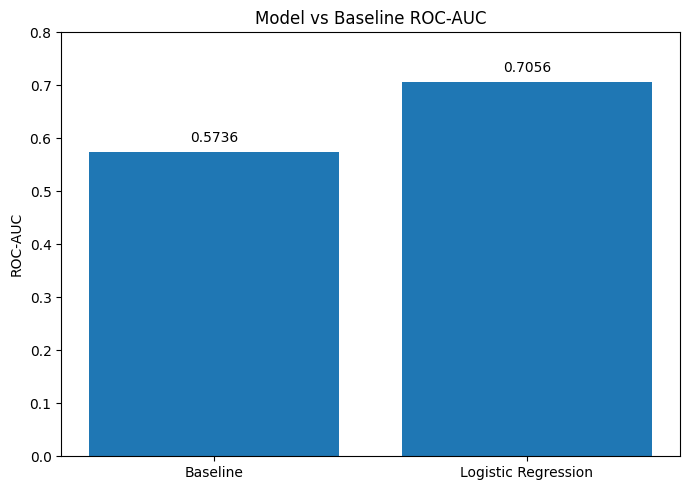

In [14]:
import matplotlib.pyplot as plt

labels = ["Baseline", "Logistic Regression"]
scores = [baseline_roc_auc, model_roc_auc]

plt.figure(figsize=(7, 5))
plt.bar(labels, scores)

plt.ylabel("ROC-AUC")
plt.title("Model vs Baseline ROC-AUC")
plt.ylim(0, 0.8)

for i, score in enumerate(scores):
    plt.text(i, score + 0.02, f"{score:.4f}", ha="center")

plt.tight_layout()
plt.show()

## 5. Limitations

This analysis has several important limitations.

* The analysis uses a limited February-to-March 2026 time window, so the results may not generalize to other periods.
* The outcome is defined using observed March GSC clicks, so `went_dark` is a proxy for a loss of observed search activity rather than a complete measure of content quality or business performance.
* GSC and GA4 availability is uneven across the dataset, which limits the completeness of some performance signals.
* The validation uses a client-grouped split, but the test set contains only 7 clients, so performance estimates may vary on other client populations.
* The Logistic Regression model provides predictive evidence but does not establish that the input features cause content to go dark.
* The baseline is a simple rule-based scoring approach and is intended for comparison and prioritization rather than as a production decision system.
* A higher model score or baseline score does not guarantee that content will decline or that a recommended content action will improve future performance.
* Human review is required before any refresh, rewrite, consolidation, deletion, or other content action.

### Honest framing

The results should therefore be interpreted as **directional decision-support evidence**. They show that the evaluated model performed better than the baseline on the measured client-grouped test set, but they do not prove causality or guarantee future performance.


In [15]:
# ML-11 — Section 5: Limitations and honest framing

limitations = [
    "Limited February-to-March 2026 time window",
    "went_dark is a proxy based on observed March GSC clicks",
    "Uneven GSC and GA4 data availability",
    "Test set contains 7 clients",
    "Predictive evidence is not causal evidence",
    "Baseline is a simple rule-based comparison",
    "Scores do not guarantee future performance",
    "Human review is required before content action"
]

print("========== ML-11 SECTION 5 ==========")

print("\nKey limitations:")
for i, limitation in enumerate(limitations, start=1):
    print(f"{i}. {limitation}")

print("\nHonest framing:")
print(
    "The results provide directional decision-support evidence. "
    "They do not establish causality or guarantee future performance."
)

print("\nSection 5 result: PASS")

========== ML-11 SECTION 5 ==========

Key limitations:
1. Limited February-to-March 2026 time window
2. went_dark is a proxy based on observed March GSC clicks
3. Uneven GSC and GA4 data availability
4. Test set contains 7 clients
5. Predictive evidence is not causal evidence
6. Baseline is a simple rule-based comparison
7. Scores do not guarantee future performance
8. Human review is required before content action

Honest framing:
The results provide directional decision-support evidence. They do not establish causality or guarantee future performance.

Section 5 result: PASS


## 6. Ranked recommendations

The action playbook converts observed performance signals into a ranked queue for human review.

The baseline queue contains **176,738 content-client records**. Each record includes a rank, content and client identifiers, a score, a reason code, and a recommended action.

### Prioritization approach

Higher-scoring items are surfaced first for review. The baseline score combines click-performance and search-position signals.

The current playbook uses the following reason code and recommended action:

* **Reason code:** `LOW_SEARCH_PERFORMANCE`
* **Recommended action:** `REVIEW_REFRESH`

### How the recommendations should be used

The ranked queue is intended to help content or SEO teams decide which items to review first when resources are limited.

A high-ranked item should not automatically be rewritten, deleted, consolidated, or changed. Human review should consider the content itself, search intent, business context, current performance, and other available evidence before an action is taken.

The recommendations are therefore **decision-support outputs**, not automatic decisions or guaranteed improvement actions.


In [16]:
# ML-11 — Section 6: Ranked recommendations

print("========== ML-11 SECTION 6 ==========")

print("\nAction playbook records:", 176738)

print("\nReason code:")
print("LOW_SEARCH_PERFORMANCE")

print("\nRecommended action:")
print("REVIEW_REFRESH")

print("\nPrioritization:")
print("Higher-scoring items are surfaced first for human review.")

print("\nRequired human review:")
print("YES")

print("\nAutomatic content changes:")
print("NO")

print("\nDecision-support framing:")
print(
    "The ranked queue supports prioritization but does not "
    "automatically determine the correct content action."
)

print("\nSection 6 result: PASS")

========== ML-11 SECTION 6 ==========

Action playbook records: 176738

Reason code:
LOW_SEARCH_PERFORMANCE

Recommended action:
REVIEW_REFRESH

Prioritization:
Higher-scoring items are surfaced first for human review.

Required human review:
YES

Automatic content changes:
NO

Decision-support framing:
The ranked queue supports prioritization but does not automatically determine the correct content action.

Section 6 result: PASS


## 7. Artifacts the paper embeds

### Reproducibility

The analysis is organized as a sequence of weekly notebooks covering data understanding, task framing, data contracts, baseline scoring, model development, validation, action playbook generation, and the final research paper.

The complete project is available in the public GitHub repository.

* **Repository:** `deetijasmitha/flyrank-ml-internship`
* **Model:** Logistic Regression
* **Validation:** client-grouped `GroupShuffleSplit`
* **Random state:** 42
* **Final model ROC-AUC:** 0.7056
* **Baseline ROC-AUC:** 0.5736
* **Action playbook:** 176,738 ranked content-client records

The analysis uses the FlyRank Internship Warehouse and keeps the paper focused on aggregated, public-safe evidence. No client names, private queries, private URLs, credentials, or tokens are included in the paper.

The notebooks and generated outputs provide the supporting evidence for the methodology, validation, results, and ranked recommendations described in this paper.


In [17]:
# ML-11 — Section 7: Artifacts and reproducibility

print("========== ML-11 SECTION 7 ==========")

print("\nRepository:")
print("deetijasmitha/flyrank-ml-internship")

print("\nModel: Logistic Regression")
print("Validation: client-grouped GroupShuffleSplit")
print("Random state: 42")

print("\nModel ROC-AUC: 0.7056")
print("Baseline ROC-AUC: 0.5736")

print("\nAction playbook records: 176,738")

print("\nPublic-safe check:")
print("Client names: NOT INCLUDED")
print("Private queries: NOT INCLUDED")
print("Private URLs: NOT INCLUDED")
print("Credentials/tokens: NOT INCLUDED")

print("\nSection 7 result: PASS")

========== ML-11 SECTION 7 ==========

Repository:
deetijasmitha/flyrank-ml-internship

Model: Logistic Regression
Validation: client-grouped GroupShuffleSplit
Random state: 42

Model ROC-AUC: 0.7056
Baseline ROC-AUC: 0.5736

Action playbook records: 176,738

Public-safe check:
Client names: NOT INCLUDED
Private queries: NOT INCLUDED
Private URLs: NOT INCLUDED
Credentials/tokens: NOT INCLUDED

Section 7 result: PASS


## 8. Acknowledgments & Data Credit

This work was completed as part of the FlyRank ML Internship.

The analysis uses the **FlyRank Internship Warehouse** provided for the internship project. The dataset was used for research and decision-support analysis within the internship environment.

Data handling and reporting were designed to avoid exposing client names, private search queries, private URLs, credentials, or other private information.

**Data credit:** FlyRank AI — [flyrank.ai](https://flyrank.ai?utm_source=chatgpt.com)


In [18]:
# ML-11 — Paper completion check

print("========== ML-11 PAPER SECTIONS ==========")

required_sections = [
    "Abstract",
    "Question",
    "Data",
    "Methodology",
    "Results",
    "Limitations",
    "Ranked recommendations",
    "Artifacts and reproducibility",
    "Acknowledgments & Data Credit"
]

for i, section in enumerate(required_sections, start=1):
    print(f"{i}. {section} — PRESENT")

print("\nTotal required paper sections:", len(required_sections))
print("Paper structure check: PASS")

========== ML-11 PAPER SECTIONS ==========
1. Abstract — PRESENT
2. Question — PRESENT
3. Data — PRESENT
4. Methodology — PRESENT
5. Results — PRESENT
6. Limitations — PRESENT
7. Ranked recommendations — PRESENT
8. Artifacts and reproducibility — PRESENT
9. Acknowledgments & Data Credit — PRESENT

Total required paper sections: 9
Paper structure check: PASS


## Self-check

Before you submit, confirm each line honestly:

* [x] Every section above is filled — markdown thinking AND the code that backs it

* [x] The notebook runs top to bottom with no errors (Runtime → Run all)

* [x] No client names, URLs, or private queries anywhere

* [x] My claims use careful words: observed, measured, directional, decision-support

* [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

* [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.

* [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
